In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/heart_disease_dataset.csv"

df = pd.read_csv(url)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,state
0,63.0,M,tap,145.0,233.0,yes,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,M,asp,160.0,286.0,no,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,M,asp,120.0,229.0,no,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,M,nap,130.0,250.0,no,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,F,aap,130.0,204.0,no,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


In [3]:
print(df.shape)

df.info()

df.describe()

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       295 non-null    float64
 1   sex       295 non-null    object 
 2   cp        292 non-null    object 
 3   trestbps  295 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       295 non-null    object 
 6   restecg   295 non-null    float64
 7   thalach   291 non-null    float64
 8   exang     295 non-null    float64
 9   oldpeak   295 non-null    float64
 10  slope     295 non-null    float64
 11  ca        291 non-null    float64
 12  thal      295 non-null    float64
 13  state     293 non-null    float64
dtypes: float64(11), object(3)
memory usage: 33.3+ KB


,age,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal,state
count,295.000000,295.000000,293.000000,295.000000,291.000000,295.000000,295.000000,295.000000,291.000000,295.000000,293.000000
mean,54.362712,131.389831,247.225256,1.003390,150.054983,0.318644,1.038644,1.589831,0.656357,4.671186,0.928328
std,9.040007,17.271361,51.819006,0.994879,22.684882,0.466742,1.170266,0.615474,0.931509,1.968377,1.229621
min,29.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,47.500000,120.000000,211.000000,0.000000,136.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,130.000000,242.000000,1.000000,153.000000,0.000000,0.700000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,140.000000,276.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,200.000000,564.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [4]:
df.isnull().sum()

,0
age,8
sex,8
cp,11
trestbps,8
chol,10
fbs,8
restecg,8
thalach,12
exang,8
oldpeak,8


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       295 non-null    object 
 2   cp        292 non-null    object 
 3   trestbps  295 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       295 non-null    object 
 6   restecg   295 non-null    float64
 7   thalach   291 non-null    float64
 8   exang     295 non-null    float64
 9   oldpeak   295 non-null    float64
 10  slope     295 non-null    float64
 11  ca        291 non-null    float64
 12  thal      295 non-null    float64
 13  state     293 non-null    float64
dtypes: float64(11), object(3)
memory usage: 33.3+ KB


In [7]:
print(df["sex"].unique())

print(df["cp"].unique())

print(df["fbs"].unique())

['M' 'F' nan]
['tap' 'asp' 'nap' 'aap' nan]
['yes' 'no' nan]


In [8]:
df["sex"] = df["sex"].map({
    "M": 0,
    "F": 1
})

df["fbs"] = df["fbs"].map({
    "no": 0,
    "yes": 1
})

df["cp"] = df["cp"].map({
    "tap": 0,
    "asp": 1,
    "nap": 2,
    "aap": 3
})

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       295 non-null    float64
 2   cp        292 non-null    float64
 3   trestbps  295 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       295 non-null    float64
 6   restecg   295 non-null    float64
 7   thalach   291 non-null    float64
 8   exang     295 non-null    float64
 9   oldpeak   295 non-null    float64
 10  slope     295 non-null    float64
 11  ca        291 non-null    float64
 12  thal      295 non-null    float64
 13  state     293 non-null    float64
dtypes: float64(14)
memory usage: 33.3 KB


In [10]:
for col in df.columns:
    df[col] = df[col].fillna(df[col].mean())

In [11]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [12]:
X = df.drop("state", axis=1)

y = df["state"]

In [13]:
print(X.shape)
print(y.shape)

(303, 13)
(303,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
print(X_train.shape)

(242, 13)


In [18]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [32]:
df = df[df["state"].isin([0,1,2,3,4])]

In [33]:
print(sorted(df["state"].unique()))

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


In [35]:
from sklearn.model_selection import train_test_split

X = df.drop("state", axis=1)
y = df["state"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(sorted(df["state"].unique()))

[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(234, 13)
(59, 13)


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(
    Dense(
        units=64,
        activation='relu',
        input_dim=X_train.shape[1]
    )
)

model.add(
    Dense(
        units=32,
        activation='relu'
    )
)

model.add(
    Dense(
        units=5,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,141 (12.27 KB)

 Trainable params: 3,141 (12.27 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.1571 - loss: 1.6654 - val_accuracy: 0.3750 - val_loss: 1.5266
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4000 - loss: 1.4991 - val_accuracy: 0.5417 - val_loss: 1.4339
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5238 - loss: 1.3622 - val_accuracy: 0.5417 - val_loss: 1.3644
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5429 - loss: 1.2516 - val_accuracy: 0.5417 - val_loss: 1.3140
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5619 - loss: 1.1633 - val_accuracy: 0.5417 - val_loss: 1.2799
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5762 - loss: 1.0897 - val_accuracy: 0.5417 - val_loss: 1.2601
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5857 - loss: 1.0364 - val_accuracy: 0.5833 - val_loss: 1.2536
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6190 - loss: 0.9930 - val_accuracy: 0.5833 - val_loss: 1.2478


In [42]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss =", loss)
print("Accuracy =", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6102 - loss: 0.8887
Loss = 0.8886680603027344
Accuracy = 0.6101694703102112


In [43]:
pred = model.predict(X_test)

pred_class = np.argmax(pred, axis=1)

print(pred_class[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
[0 0 0 3 0 0 3 0 3 0]


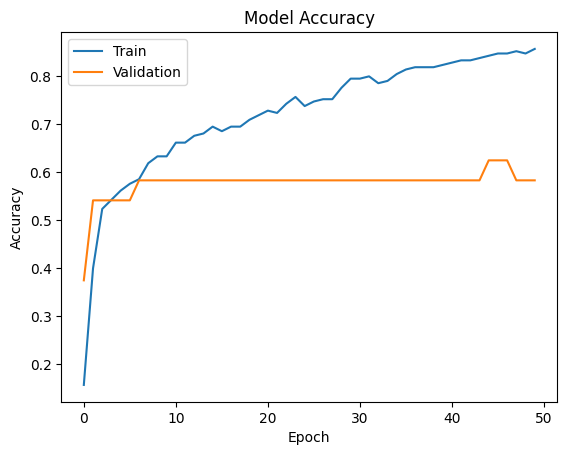

In [44]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

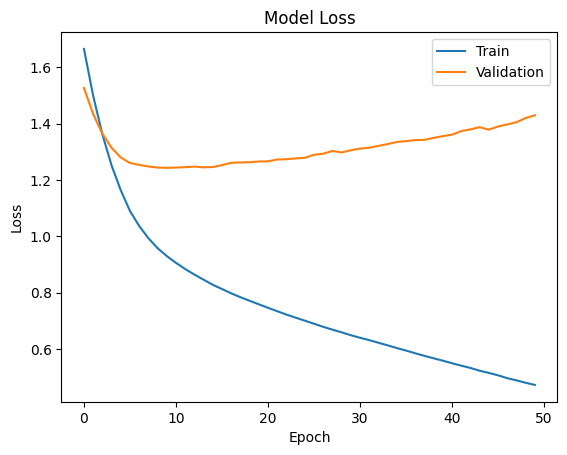

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [46]:
from sklearn.metrics import confusion_matrix

pred = model.predict(X_test)

pred_class = np.argmax(pred, axis=1)

cm = confusion_matrix(
    y_test,
    pred_class
)

print(cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[33  2  0  0  0]
 [ 5  0  0  4  0]
 [ 0  1  2  5  0]
 [ 0  2  2  1  0]
 [ 0  0  0  2  0]]


In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_class
    )
)

              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90        35
         1.0       0.00      0.00      0.00         9
         2.0       0.50      0.25      0.33         8
         3.0       0.08      0.20      0.12         5
         4.0       0.00      0.00      0.00         2

    accuracy                           0.61        59
   macro avg       0.29      0.28      0.27        59
weighted avg       0.59      0.61      0.59        59



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
